In [2]:
import src.analysis_functions as af
import src.data_functions as df
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 18})
import numpy as np
import os
import pandas as pd
import importlib

importlib.reload(af)
importlib.reload(df)

<module 'src.data_functions' from 'C:\\Users\\owner\\Documents\\Projects\\rnaseq_correlations\\src\\data_functions.py'>

<Axes: xlabel='$\\lambda$', ylabel='$\\rho(\\lambda)$'>

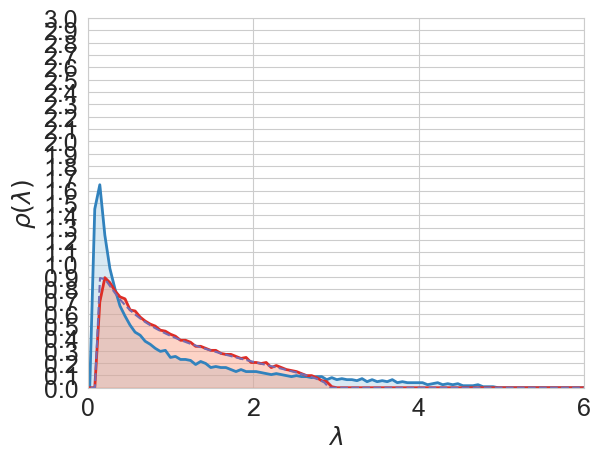

In [14]:
# generate a NxP random matrix
np.random.seed(0)
N=4000
P = 2000
sigma=0.9
A=np.random.normal(0,sigma,(P,P))
H=np.dot(A,A.transpose())/P+(1-sigma**2)*np.identity(P)
L=np.linalg.cholesky(H)
data = np.random.normal(0,1,(N,P))
data = L@data.T
data = data.T
# get the eigenvalues of the covariance matrix
pcs, pcs1 = af.get_eig_dist(data, norm=False, log=False, norm_method='sum')
# plot histograms of eigenvalues
df.plot_eig_dist(pcs, pcs1,N, 6, 3,101)

In [74]:
len(np.mean(M,axis=0))

2000

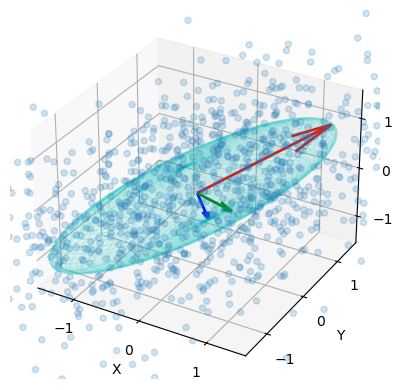

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


# Generate random data
np.random.seed(0)
N=1000
P = 3
sigma=0.7
A=np.random.normal(0,sigma,(P,P))
H=np.dot(A,A.transpose())/P+(1-sigma**2)*np.identity(P)
L=np.linalg.cholesky(H)
data = np.random.normal(0,1,(N,P))
data = L@data.T
data = data.T
# Perform PCA
pca = PCA(n_components=3)
pca.fit(data)
components = pca.components_
explained_variance = pca.explained_variance_

# Plot the 3D scatter plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data[:, 0], data[:, 1], data[:, 2], alpha=0.2)

# Plot the principal components as arrows
origin = np.mean(data, axis=0)
colors = ['r', 'g', 'b']
for i in range(3):
    vector = components[i] * explained_variance[i]
    ax.quiver(*origin, *vector, color=colors[i], linewidth=2)

# Create an ellipsoid representing the covariance matrix
covariance_matrix = np.cov(data, rowvar=False)
eigvals, eigvecs = np.linalg.eigh(covariance_matrix)
order = eigvals.argsort()[::-1]
eigvals = eigvals[order]
eigvecs = eigvecs[:, order]

# Radii of the ellipsoid
radii = eigvals

# Generate ellipsoid
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)
x = radii[0] * np.outer(np.cos(u), np.sin(v))
y = radii[1] * np.outer(np.sin(u), np.sin(v))
z = radii[2] * np.outer(np.ones_like(u), np.cos(v))

# Rotate the ellipsoid
for i in range(len(x)):
    for j in range(len(x)):
        [x[i, j], y[i, j], z[i, j]] = np.dot([x[i, j], y[i, j], z[i, j]], eigvecs.T)

# Plot the ellipsoid
ax.plot_wireframe(x + origin[0], y + origin[1], z + origin[2], color='c', alpha=0.1)

# Set plot limits and labels
ax.set_xlim([-1.5, 1.5])
ax.set_ylim([-1.5, 1.5])
ax.set_zlim([-1.5, 1.5])
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_xticks([-1, 0, 1])
ax.set_yticks([-1, 0, 1])
ax.set_zticks([-1, 0, 1])

plt.show()


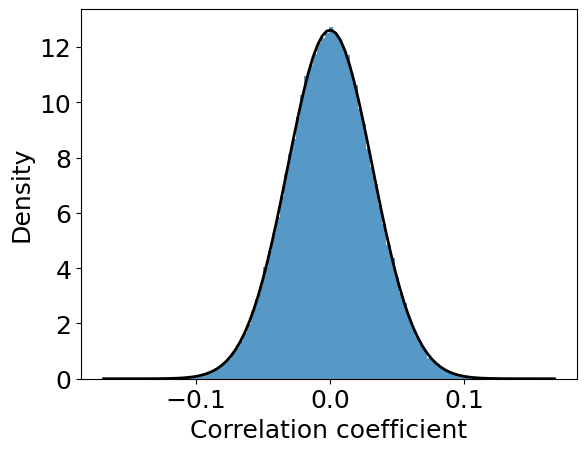

In [3]:
from scipy.stats import norm
# generate a NxP random matrix
N = 1000
P = 1000

M = np.random.normal(loc=0,scale=1,size=(N,P))
# calculate the covariance matrix
C = np.cov(M.T)
# plot a histogram of the correlation coefficients of all non diagonal elements
plt.hist(C[np.triu_indices(P, k=1)], bins=100, density=True, alpha=0.75)
plt.xlabel('Correlation coefficient')
plt.ylabel('Density')
# fit a gaussian to the histogram
mu, std = norm.fit(C[np.triu_indices(P, k=1)])
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2)
plt.show()

In [1]:
# generate a sparse random matrix
N = 1000
P = 2000
k = 6 # average number of non zero elements in each row
M = np.zeros((N,P))
for i in range(N):
    # generate k random indices and values for a poisson distribution
    M[i,np.random.choice(P,k,replace=False)] = np.random.poisson(10,k)

pcs, pcs1 = af.get_eig_dist(M, norm=True, log=False)
# plot histograms of eigenvalues
df.plot_eig_dist(pcs, pcs1,N, 10, 0.8,101)

NameError: name 'np' is not defined